# Phase 6 — Feature engineering

**Input:** `data/clean.parquet` · **Output:** `data/features.parquet` (final feature set), `reports/data_dictionary.md`,
and the reusable preprocessor in [`src/features.py`](../src/features.py).

Steps:
1. **Create** new row-wise features (time, night, weather, highway, road features).
2. **Hold-out split** (80% train / 20% test, stratified on Severity) so that every decision below is made on training data only.
3. **Select** features on the training split: drop near-constant and redundant columns, rank the rest by mutual information.
4. **Encode / scale**: fit the preprocessor on the training split only, apply it to the test split, verify the result.

| Kind | Examples | Where | Why |
|---|---|---|---|
| **Row-wise** (use only the row itself) | hour, is_rush_hour, season, is_highway | `add_features()` | Safe before the split: no information from other rows |
| **Fitted** (learn from many rows) | median imputation, one-hot, City/County frequency, KMeans `location_cluster`, scaling | `make_preprocessor()` (sklearn `ColumnTransformer`) | Fitted on the **training split only**, otherwise test data leaks into training |

> Runs in the WSL environment (`~/venvs/usacc`) because Windows Smart App Control blocks scikit-learn on this PC.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

sys.path.insert(0, "..")
from src.features import (add_features, make_preprocessor, FrequencyEncoder, CANDIDATES, FEATURES, NUM_ALL, NUM,
                          CAT, FREQ, ROAD, TARGET, HIGHWAY, SEED, DROP, NEAR_CONSTANT, REDUNDANT)

DATA, REPORTS = Path("../data"), Path("../reports")
clean = pd.read_parquet(DATA / "clean.parquet")
cand = add_features(clean)  # all candidate features + target
feat = cand                 # name used by the signal checks below
print(clean.shape, "->", cand.shape, f"({len(CANDIDATES)} candidate inputs + target)")
cand.head(3).T

(495532, 36) -> (495532, 42) (41 candidate inputs + target)


,0,1,2
Start_Lat,30.641211,38.990562,34.661189
Start_Lng,-91.153481,-77.39907,-120.492822
Temperature(F),77.0,45.0,68.0
Humidity(%),62.0,48.0,73.0
Pressure(in),29.92,29.91,29.79
Visibility(mi),10.0,10.0,10.0
Wind_Speed(mph),5.0,5.0,13.0
Precipitation(in),0.0,0.0,0.0
precip_missing,0,0,0
hour,10,23,13


## Row-wise features: do they carry signal?

In [2]:
# Share of rows with each flag, and share of high-impact (Severity 3-4) accidents with / without it
hi = feat[TARGET].ge(3)
flags = ["is_weekend", "is_rush_hour", "is_night", "bad_weather", "is_highway"]
pd.DataFrame({
    "rows_with_flag_%": feat[flags].mean() * 100,
    "sev3_4_%_flag=0": [hi[feat[f] == 0].mean() * 100 for f in flags],
    "sev3_4_%_flag=1": [hi[feat[f] == 1].mean() * 100 for f in flags],
    "sev4_%_flag=0": [feat.loc[feat[f] == 0, TARGET].eq(4).mean() * 100 for f in flags],
    "sev4_%_flag=1": [feat.loc[feat[f] == 1, TARGET].eq(4).mean() * 100 for f in flags],
}).round(1)

,rows_with_flag_%,sev3_4_%_flag=0,sev3_4_%_flag=1,sev4_%_flag=0,sev4_%_flag=1
is_weekend,15.9,19.2,21.7,2.4,3.5
is_rush_hour,39.1,19.6,19.6,3.0,1.9
is_night,30.8,19.9,19.1,2.2,3.5
bad_weather,12.7,19.5,20.7,2.6,2.6
is_highway,50.3,11.2,27.9,2.2,3.0


**Reading:** `is_highway` is the strongest new flag — highway accidents are about 2.5× as likely to be
high impact (Severity 3–4) as non-highway ones, and Severity 4 is more frequent there too.
Night and weekend raise Severity 4; rush hour slightly lowers it (matches the EDA).

In [3]:
# is_highway check: most common streets on each side of the rule
s = clean["Street"]
hw = s.str.contains(HIGHWAY, regex=True, na=False)
pd.DataFrame({"matched (highway)": s[hw].value_counts().index[:12],
              "not matched": s[~hw].value_counts().index[:12]})

,matched (highway),not matched
0,I-95 N,Main St
1,I-95 S,S Orange Blossom Trl
2,I-5 N,SW 137th Ave
3,I-10 E,Main St
4,I-10 W,N Main St
5,I-5 S,E Main St
6,I-80 W,SW 8th St
7,I-80 E,Biscayne Blvd
8,I-405 N,W Main St
9,I-75 N,FDR Dr S


In [4]:
pd.concat([
    feat.groupby("season")[TARGET].apply(lambda y: y.ge(3).mean() * 100).rename("sev3_4_%"),
    feat["season"].value_counts().rename("rows"),
], axis=1).round(1)

,sev3_4_%,rows
season,,
Autumn,18.5,133994
Spring,21.5,108909
Summer,23.1,108023
Winter,16.7,144606


In [5]:
pd.concat([
    feat.groupby("road_feature_count")[TARGET].apply(lambda y: y.ge(3).mean() * 100).rename("sev3_4_%"),
    feat["road_feature_count"].value_counts().rename("rows"),
], axis=1).round(1)

,sev3_4_%,rows
road_feature_count,,
0,22.3,347564
1,15.8,99442
2,8.0,39060
3,8.6,7966
4,9.5,1311
5,6.9,173
6,6.7,15
7,0.0,1


**Reading:** accidents with **no** road feature nearby are the most often high-impact (22%: open road / highway).
One feature (signal, crossing, stop...) drops it to 16%, two or more to ~8%: slower, urban locations mean less impact.

## Hold-out split (before any selection or fitting)

80% train / 20% test, stratified on Severity, seed 42. Feature selection, imputation, encoding, clustering and
scaling below all **learn only from the training split**; the test split is only transformed, never learned from.
(The modelling phase will split the training part again into train / validation.)

In [6]:
train, test = train_test_split(cand, test_size=0.2, stratify=cand[TARGET], random_state=SEED)
print(f"train {len(train):,} rows / test {len(test):,} rows")
pd.DataFrame({"train_%": train[TARGET].value_counts(normalize=True).sort_index() * 100,
              "test_%": test[TARGET].value_counts(normalize=True).sort_index() * 100}).round(2)

train 396,425 rows / test 99,107 rows


,train_%,test_%
Severity,,
1,0.86,0.86
2,79.52,79.52
3,17.03,17.03
4,2.59,2.60


## Feature selection (training split only)

Three checks, from simplest to most informative:
1. **Near-constant flags:** a yes/no column that is 1 in fewer than 0.1% of rows carries almost no information.
2. **Redundant columns:** if two columns are almost the same (|correlation| > 0.85), keep only one
   (the one more related to Severity, by mutual information).
3. **Mutual information (MI):** how much knowing a feature reduces uncertainty about Severity. Works for
   non-linear relations and categories, unlike correlation. Used to rank features and to break ties in step 2.

In [7]:
flags = [c for c in NUM_ALL if set(train[c].dropna().unique()) <= {0, 1}]
share = train[flags].mean().sort_values()
near_const = share[share < NEAR_CONSTANT].index.tolist()
(share.head(8) * 100).round(3).to_frame("% of training rows = 1")

,% of training rows = 1
Roundabout,0.002
Bump,0.041
Traffic_Calming,0.092
No_Exit,0.246
Give_Way,0.470
Railway,0.870
Amenity,1.233
Station,2.605


In [8]:
# Mutual information with Severity on a 60K-row training sample (MI is slow on all rows)
mi_s = train.sample(60_000, random_state=SEED)
X_mi = mi_s[CANDIDATES].copy()
for c in CAT + FREQ:                              # categories -> integer codes for MI
    X_mi[c] = X_mi[c].astype("category").cat.codes
X_mi = X_mi.fillna(X_mi.median())
CONTINUOUS = ["Start_Lat", "Start_Lng", "Temperature(F)", "Humidity(%)", "Pressure(in)",
              "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]
mi = pd.Series(mutual_info_classif(X_mi, mi_s[TARGET], discrete_features=[c not in CONTINUOUS for c in CANDIDATES],
                                   random_state=SEED), index=CANDIDATES).sort_values(ascending=False)
mi.round(4).to_frame("mutual_information")

,mutual_information
City,0.1539
Source,0.0899
County,0.0837
Start_Lng,0.0811
Start_Lat,0.0676
year,0.0556
State,0.0308
Wind_Speed(mph),0.0273
is_highway,0.0243
precip_missing,0.0212


In [9]:
corr = train[NUM_ALL].corr().abs()
pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
             .sort_values(ascending=False).rename("abs_corr").reset_index())
redundant, decisions = [], []
for a, b, r in pairs[pairs["abs_corr"] > REDUNDANT].itertuples(index=False):
    if a in redundant or b in redundant:
        continue
    loser = a if mi[a] < mi[b] else b              # keep the one more informative about Severity
    redundant.append(loser)
    decisions.append((a, b, round(r, 3), loser))
print("Most correlated pairs:")
print(pairs.head(6).round(3).to_string(index=False))
pd.DataFrame(decisions, columns=["feature_1", "feature_2", "|r|", "dropped (lower MI)"])

Most correlated pairs:
           level_0        level_1  abs_corr
          is_night    civil_night     0.891
    nautical_night    astro_night     0.876
       civil_night nautical_night     0.873
          is_night nautical_night     0.778
       civil_night    astro_night     0.765
road_feature_count       Crossing     0.749


,feature_1,feature_2,|r|,dropped (lower MI)
0,is_night,civil_night,0.891,is_night
1,nautical_night,astro_night,0.876,nautical_night


In [10]:
selected_drop = set(near_const) | set(redundant)
assert selected_drop == set(DROP), (selected_drop, set(DROP))  # src/features.py matches the evidence
print(f"{len(CANDIDATES)} candidates -> drop {len(DROP)} -> {len(FEATURES)} final inputs")
pd.Series(DROP, name="reason").to_frame()

41 candidates -> drop 5 -> 36 final inputs


,reason
Roundabout,near-constant (1 in < 0.1% of rows); still cou...
Bump,near-constant (1 in < 0.1% of rows); still cou...
Traffic_Calming,near-constant (1 in < 0.1% of rows); still cou...
is_night,"redundant: |r| = 0.89 with civil_night, which ..."
nautical_night,"redundant: |r| = 0.88 with astro_night, which ..."


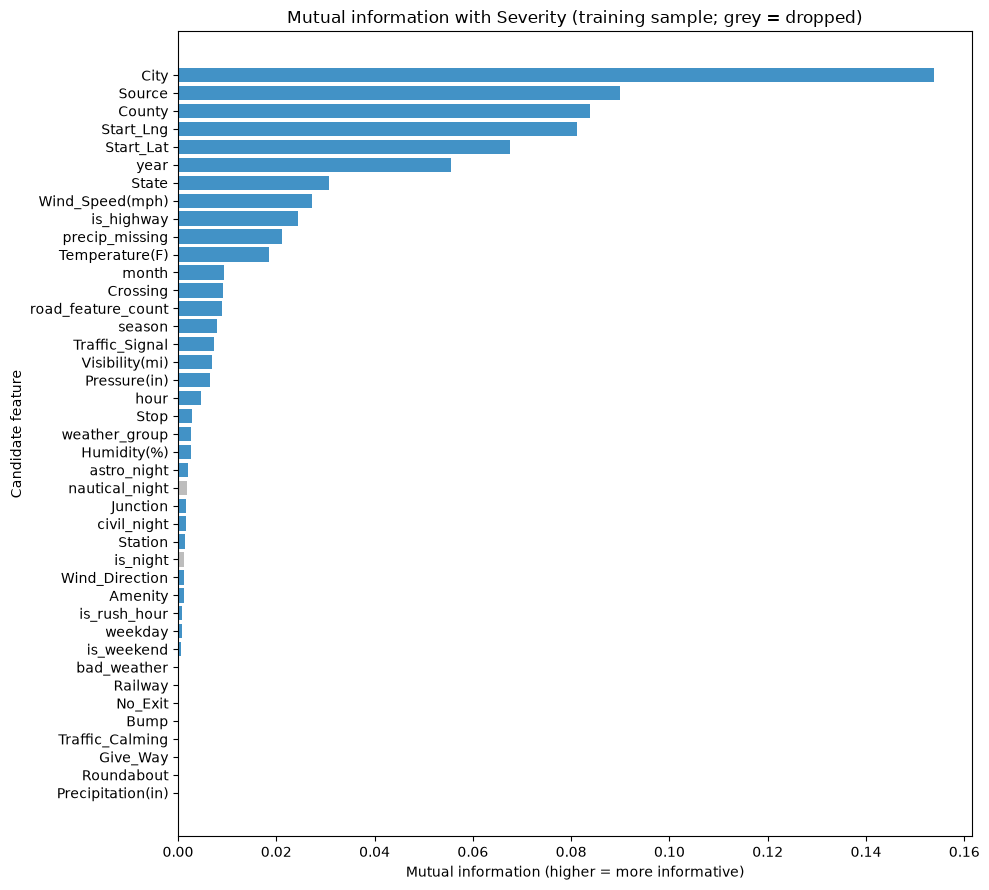

In [11]:
fig, ax = plt.subplots(figsize=(10, 9))
colors = ["#bdbdbd" if c in DROP else "#4292c6" for c in mi.index]
ax.barh(mi.index[::-1], mi.values[::-1], color=colors[::-1])
ax.set(title="Mutual information with Severity (training sample; grey = dropped)",
       xlabel="Mutual information (higher = more informative)", ylabel="Candidate feature")
fig.tight_layout()
fig.savefig(REPORTS / "figures" / "14_feature_mutual_information.png", dpi=120)

**Reading:** location (`City`, `County`, lat/lng, `State`), the data provider (`Source`), `year`, wind speed and
`is_highway` are the most informative features. Caution: MI is biased upward for columns with thousands of values
(City, County), so their rank is partly inflated. The dropped columns are either almost always 0 or near-copies of another column.
Weak features (e.g. single weather numbers) are **kept**: tree models can combine them, and the EDA showed they
matter together (weather + night + road), even if each one alone is weak.

### Final feature set and why

| Group | Final features | Why they are kept |
|---|---|---|
| Location | Start_Lat, Start_Lng, State, City, County (+ 50 location clusters at fit time) | Severity differs a lot by region and road network |
| Road | is_highway, road_feature_count, Junction, Traffic_Signal, Crossing, Stop, Station, Railway, Give_Way, No_Exit, Amenity | Highway vs city street is the strongest road signal (EDA chart 8, chi-square V = 0.22) |
| Time | hour, weekday, month, year, season, is_weekend, is_rush_hour | Night / weekend / year patterns in EDA; `year` captures reporting drift |
| Light | civil_night, astro_night | Night raises Severity 4 (x1.6); `is_night` and `nautical_night` were near-copies with less information |
| Weather | Temperature, Humidity, Pressure, Visibility, Wind_Speed, Wind_Direction, Precipitation, precip_missing, weather_group, bad_weather | Weak alone but plausible causes of delay; trees use them in combination |
| Provider | Source | Strongest single link with Severity (V = 0.29); kept, but its effect must be tested with/without in modelling |

In [12]:
feat = cand[FEATURES + [TARGET]]
feat.to_parquet(DATA / "features.parquet", index=False)
print(f"features.parquet: {feat.shape[0]:,} rows x {feat.shape[1]} cols "
      f"({len(FEATURES)} model inputs + target), {(DATA / 'features.parquet').stat().st_size / 1e6:.1f} MB")

features.parquet: 495,532 rows x 37 cols (36 model inputs + target), 15.7 MB


## Encoding and scaling: fit on train, apply to test

`make_preprocessor(scale=False, use_source=True)` returns one `ColumnTransformer`:

| Block | Columns | Transform |
|---|---|---|
| `num` | numeric weather, lat/lng, time, flags, road features | median imputation (+ `StandardScaler` if `scale=True`) |
| `cat` | State, Source, weather_group, Wind_Direction, season | one-hot (`handle_unknown="ignore"`) |
| `freq` | City, County | frequency encoding: share of **training** rows in that city/county (unseen -> 0) |
| `cluster` | Start_Lat, Start_Lng | KMeans (50 clusters) -> nearest cluster id -> one-hot |

Why these choices: one-hot for columns with few values (at most 49); frequency encoding for thousands of cities
(one-hot would create ~9,000 mostly-empty columns); median instead of mean because weather values are skewed;
scaling only for linear / distance-based models (trees are not affected by scale).

In [13]:
pre = make_preprocessor().fit(train[FEATURES])
Xtr, Xte = pre.transform(train[FEATURES]), pre.transform(test[FEATURES])
names = pre.get_feature_names_out()

assert Xtr.shape[1] == Xte.shape[1] == len(names)
assert not np.isnan(Xtr).any() and not np.isnan(Xte).any()
print(f"train {Xtr.shape}, test {Xte.shape}: no missing values after imputation")
pd.Series({block: s.stop - s.start for block, s in pre.output_indices_.items() if s.stop > s.start},
          name="output_columns")

train (396425, 165), test (99107, 165): no missing values after imputation


num        29
cat        84
freq        2
cluster    50
Name: output_columns, dtype: int64

In [14]:
# Leakage check: test cities never seen in training get frequency 0 (nothing learned from test)
unseen = ~test["City"].isin(train["City"])
city_col = list(names).index("City_freq")
print(f"test rows in cities unseen in train: {unseen.sum():,} ({unseen.mean():.2%})")
assert (Xte[unseen.to_numpy(), city_col] == 0).all()

# The median used to fill missing values comes from the training split
imp = pre.named_transformers_["num"][0]
print("Temperature median used for missing values (train):", imp.statistics_[NUM.index("Temperature(F)")])

test rows in cities unseen in train: 399 (0.40%)
Temperature median used for missing values (train): 64.0


In [15]:
# Scaled version (Logistic Regression): train columns have mean 0 / std 1; test is close but not exact
pre_s = make_preprocessor(scale=True).fit(train[FEATURES])
Ztr, Zte = pre_s.transform(train[FEATURES]), pre_s.transform(test[FEATURES])
k = len(NUM)
pd.DataFrame({"train_mean": Ztr[:, :k].mean(0), "train_std": Ztr[:, :k].std(0),
              "test_mean": Zte[:, :k].mean(0)}, index=NUM).round(3).head(8)

,train_mean,train_std,test_mean
Start_Lat,0.0,1.0,0.002
Start_Lng,0.0,1.0,0.005
Temperature(F),0.0,1.0,-0.000
Humidity(%),0.0,1.0,-0.004
Pressure(in),-0.0,1.0,-0.004
Visibility(mi),0.0,1.0,0.006
Wind_Speed(mph),-0.0,1.0,0.003
Precipitation(in),-0.0,1.0,-0.007


In [16]:
print("without Source:", make_preprocessor(use_source=False).fit(train[FEATURES]).transform(test[FEATURES]).shape)

# Frequency encoder unit check: unseen city -> 0, known city -> its training share
fe = FrequencyEncoder().fit(pd.DataFrame({"City": ["A", "A", "B", "C"]}))
out = fe.transform(pd.DataFrame({"City": ["A", "B", "Z"]})).ravel()
assert np.allclose(out, [0.5, 0.25, 0.0])
out

without Source: (99107, 162)


array([0.5 , 0.25, 0.  ])

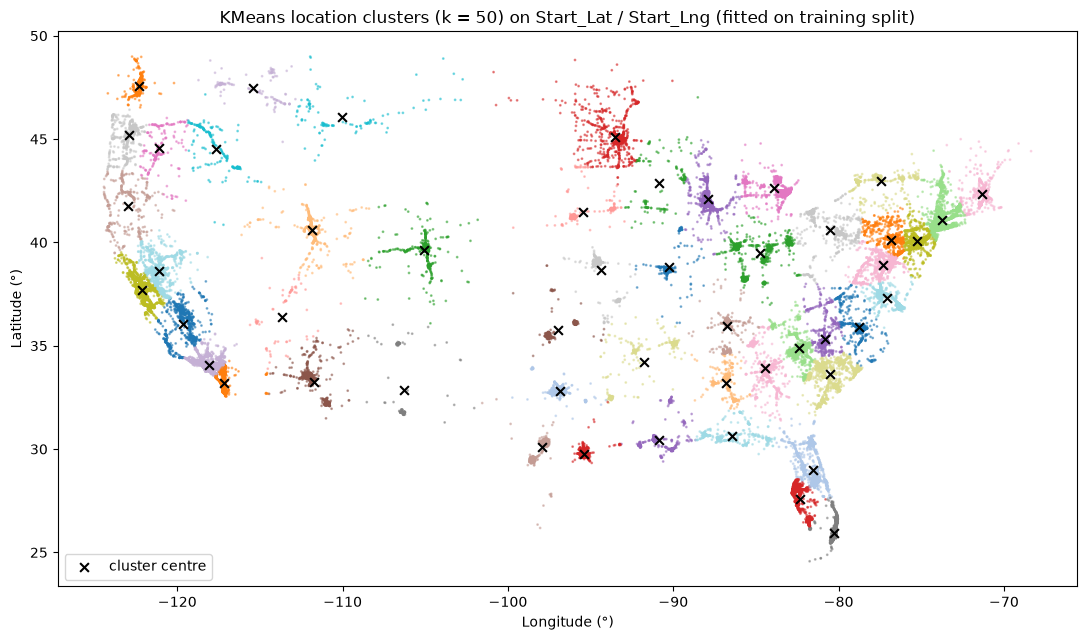

In [17]:
# The 50 location clusters (fitted on the training split)
km = pre.named_transformers_["cluster"][0].km_
show = train.sample(50_000, random_state=SEED)
labels = km.predict(show[["Start_Lat", "Start_Lng"]].to_numpy())
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.scatter(show["Start_Lng"], show["Start_Lat"], c=labels, cmap="tab20", s=1, alpha=0.5)
ax.scatter(km.cluster_centers_[:, 1], km.cluster_centers_[:, 0], c="k", marker="x", s=40, label="cluster centre")
ax.set(title="KMeans location clusters (k = 50) on Start_Lat / Start_Lng (fitted on training split)",
       xlabel="Longitude (°)", ylabel="Latitude (°)")
ax.set_aspect(1.25)
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(REPORTS / "figures" / "13_location_clusters.png", dpi=120)

**Reading:** clusters follow accident density: many small clusters in dense metro areas (LA, Bay Area,
Florida, the East Coast) and a few large ones in the empty Mountain West. Each cluster acts as a learned "region".

## Data dictionary

In [18]:
DICT = {  # column: (built from, description)
    "Start_Lat": ("raw", "Latitude of the accident start (°)"),
    "Start_Lng": ("raw", "Longitude of the accident start (°)"),
    "Temperature(F)": ("raw", "Air temperature (°F); impossible values set to NaN in Phase 4"),
    "Humidity(%)": ("raw", "Relative humidity (%)"),
    "Pressure(in)": ("raw", "Air pressure (inHg)"),
    "Visibility(mi)": ("raw", "Visibility (miles)"),
    "Wind_Speed(mph)": ("raw", "Wind speed (mph)"),
    "Precipitation(in)": ("raw", "Precipitation (inches); missing -> 0 in Phase 4"),
    "precip_missing": ("Phase 4", "1 if Precipitation was missing and filled with 0"),
    "hour": ("Start_Time", "Hour of day, local time (0-23)"),
    "weekday": ("Start_Time", "Day of week (0 = Monday ... 6 = Sunday)"),
    "month": ("Start_Time", "Month (1-12)"),
    "year": ("Start_Time", "Year (2016-2023)"),
    "is_weekend": ("weekday", "1 if Saturday or Sunday"),
    "is_rush_hour": ("weekday, hour", "1 if weekday and hour in 7-9 or 16-19"),
    "is_night": ("Sunrise_Sunset", "1 if Night by sunrise/sunset"),
    "civil_night": ("Civil_Twilight", "1 if Night by civil twilight"),
    "nautical_night": ("Nautical_Twilight", "1 if Night by nautical twilight"),
    "astro_night": ("Astronomical_Twilight", "1 if Night by astronomical twilight"),
    "bad_weather": ("weather_group", "1 if Rain, Heavy rain / Thunderstorm, Snow / Ice or Fog / Haze / Smoke"),
    "road_feature_count": ("road features", "Number of road features near the accident (0-12)"),
    "is_highway": ("Street", "1 if street name looks like a highway (I-, US-, state route XX-, Interstate, Hwy, Highway, Fwy, Expy, Tpke, Beltway, State Pkwy, Route...)"),
    **{c: ("raw", f"1 if a {c.replace('_', ' ').lower()} is near the accident") for c in ROAD},
    "State": ("raw", "US state (49 values)"),
    "Source": ("raw", "Data provider (Source1-3); records severity differently (EDA chart 12)"),
    "weather_group": ("Weather_Condition", "9 groups: Clear, Cloudy, Rain, Heavy rain / Thunderstorm, Snow / Ice, Fog / Haze / Smoke, Windy, Other, Unknown"),
    "Wind_Direction": ("raw", "16 compass points + CALM + VAR + Unknown"),
    "season": ("month", "Winter (Dec-Feb), Spring, Summer, Autumn"),
    "City": ("raw", "City (~9,500 values)"),
    "County": ("raw", "County (~1,600 values)"),
    TARGET: ("raw", "TARGET: impact on traffic, 1 (least) to 4 (most). Not injuries."),
}
ENCODING = {**dict.fromkeys(NUM_ALL, "median impute (+ scale for LogReg)"),
            **dict.fromkeys(CAT, "one-hot"), **dict.fromkeys(FREQ, "frequency (train shares)"),
            TARGET: "label"}
assert set(DICT) == set(cand.columns)

dd = pd.DataFrame([(c, str(feat[c].dtype), *DICT[c], ENCODING[c]) for c in feat.columns],
                  columns=["column", "dtype", "built_from", "description", "pipeline_encoding"])


def to_md(t):
    rows = [t.columns.tolist(), ["---"] * t.shape[1], *t.astype(str).values.tolist()]
    return "\n".join("| " + " | ".join(r) + " |" for r in rows)


(REPORTS / "data_dictionary.md").write_text(
    "# Data dictionary — `data/features.parquet`\n\n"
    f"{len(feat):,} rows, {len(FEATURES)} model inputs + target. "
    "Fitted encodings (last column) are applied by `src/features.py::make_preprocessor()` on the training set only.\n\n"
    "Extra fitted feature: **location_cluster** = KMeans (k = 50, seed 42) on Start_Lat / Start_Lng, one-hot encoded.\n\n"
    "Not used as inputs: the 5 columns dropped in feature selection (end of file), Street (-> is_highway), Weather_Condition (-> weather_group), Zipcode (too many values; City/County cover location), "
    "Start_Time (-> hour/weekday/month/year), light columns (-> *_night flags).\n\n"
    + to_md(dd)
    + "\n\n## Dropped during feature selection (notebook 04)\n\n"
    + to_md(pd.Series(DROP, name="reason").rename_axis("column").reset_index()) + "\n",
    encoding="utf-8")
dd

,column,dtype,built_from,description,pipeline_encoding
0,Start_Lat,float64,raw,Latitude of the accident start (°),median impute (+ scale for LogReg)
1,Start_Lng,float64,raw,Longitude of the accident start (°),median impute (+ scale for LogReg)
2,Temperature(F),float64,raw,Air temperature (°F); impossible values set to...,median impute (+ scale for LogReg)
3,Humidity(%),float64,raw,Relative humidity (%),median impute (+ scale for LogReg)
4,Pressure(in),float64,raw,Air pressure (inHg),median impute (+ scale for LogReg)
5,Visibility(mi),float64,raw,Visibility (miles),median impute (+ scale for LogReg)
6,Wind_Speed(mph),float64,raw,Wind speed (mph),median impute (+ scale for LogReg)
7,Precipitation(in),float64,raw,Precipitation (inches); missing -> 0 in Phase 4,median impute (+ scale for LogReg)
8,precip_missing,int8,Phase 4,1 if Precipitation was missing and filled with 0,median impute (+ scale for LogReg)
9,hour,int8,Start_Time,"Hour of day, local time (0-23)",median impute (+ scale for LogReg)
